ADVERTISING DATASET LOADED SUCCESSFULLY
Rows    : 200
Columns : 4

First 5 Records
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9

DATA QUALITY REPORT
Duplicate Records : 0
Missing Values    : 0
No duplicate records found.

Quality Report
          Data Type  Missing Values  Unique Values
TV          float64               0            190
Radio       float64               0            167
Newspaper   float64               0            172
Sales       float64               0            121

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-

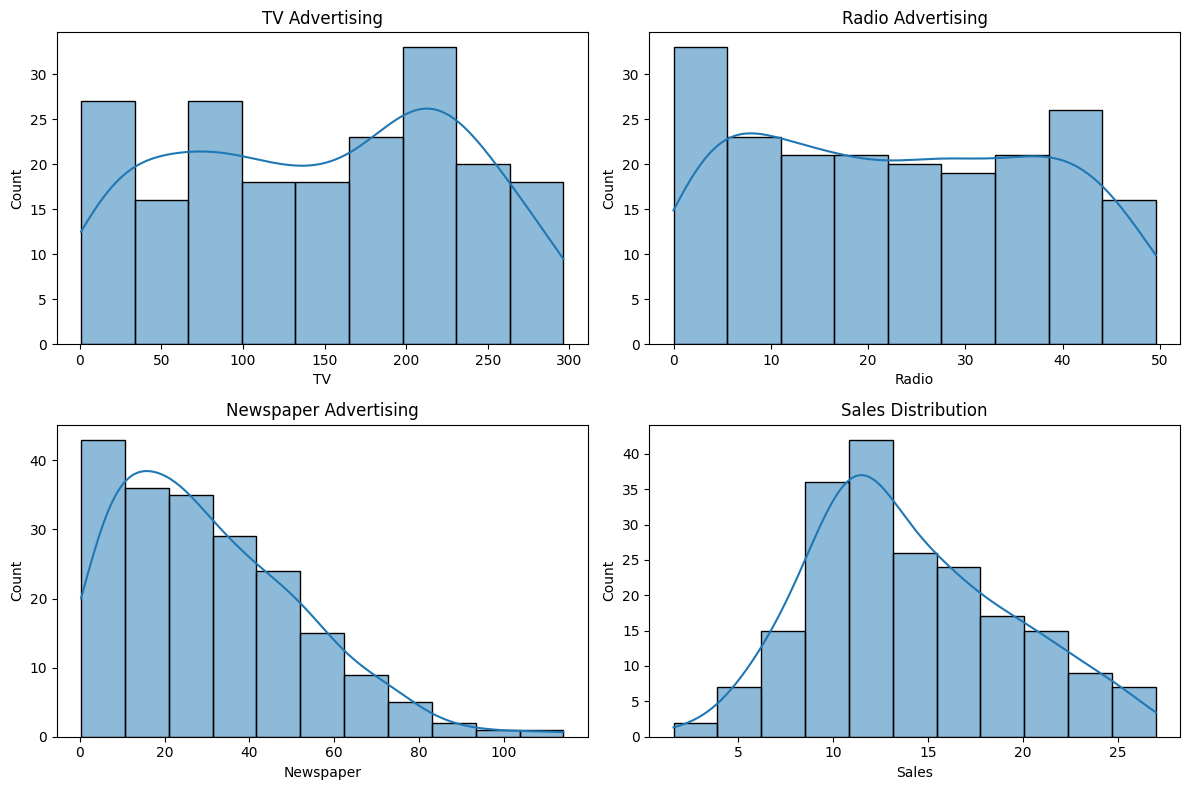

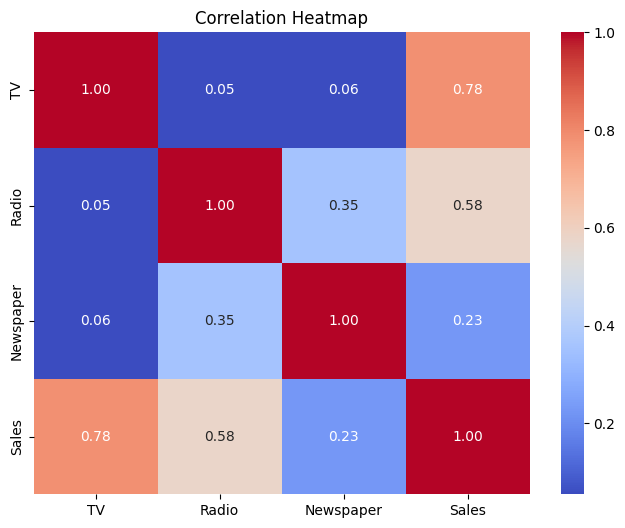

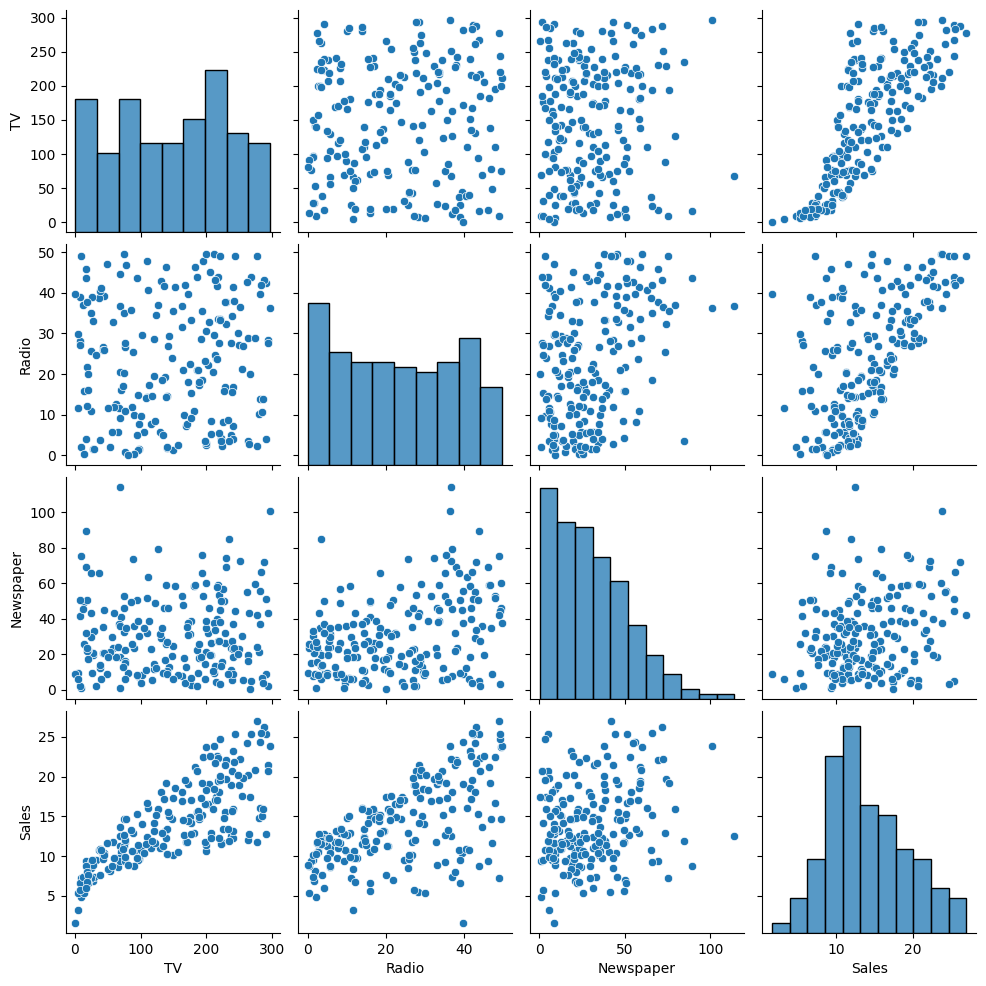

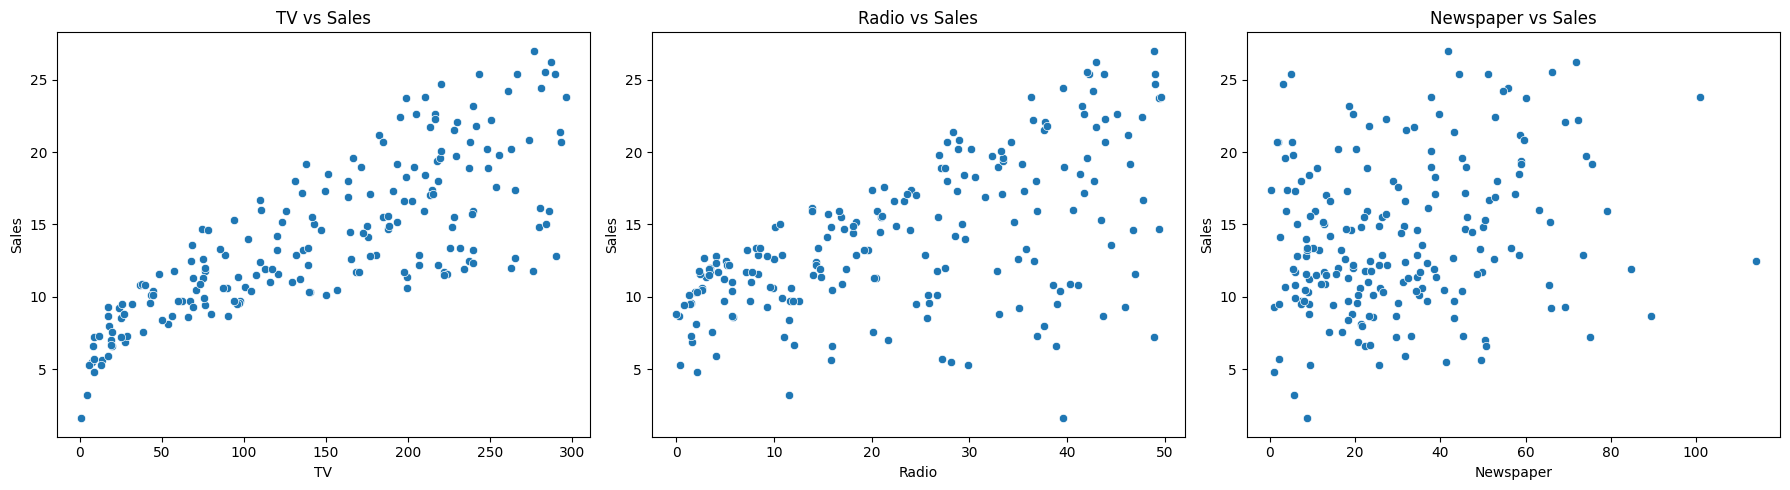

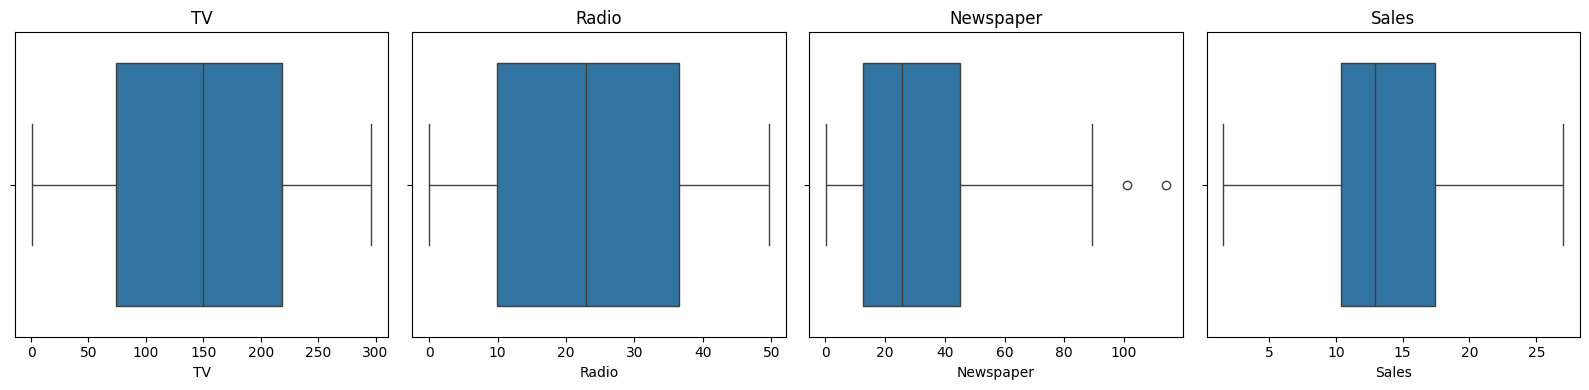


BUSINESS INSIGHTS
Sales        1.000000
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64

Observation:
TV advertising shows the strongest positive relationship with Sales.
Radio advertising also contributes significantly to Sales.
Newspaper advertising has comparatively lower influence.

Features:
['TV', 'Radio', 'Newspaper']

Target:
Sales

Train-Test Split
X_train Shape : (160, 3)
X_test Shape  : (40, 3)
y_train Shape : (160,)
y_test Shape  : (40,)

MODEL COMPARISON
Linear Regression    R² Score = 0.8703 (+/- 0.0718)
Decision Tree        R² Score = 0.9021 (+/- 0.0415)
Random Forest        R² Score = 0.9660 (+/- 0.0136)

Model Ranking
               Model  R2 Score
2      Random Forest  0.965986
1      Decision Tree  0.902083
0  Linear Regression  0.870265


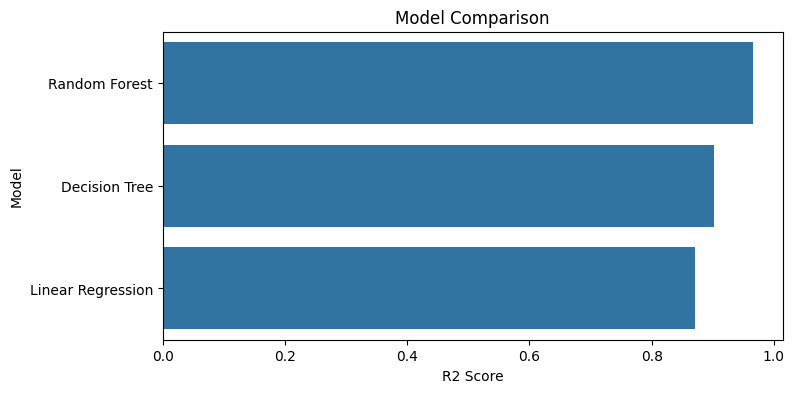


Best Model Selected:
Random Forest

Best Model Trained Successfully!

MODEL PERFORMANCE
R² Score : 0.9826
MAE      : 0.6131
MSE      : 0.5481
RMSE     : 0.7403

Sample Predictions
   Actual Sales  Predicted Sales
0          16.9            17.73
1          22.4            21.74
2          21.4            20.87
3           7.3             6.82
4          24.7            23.10
5          12.6            13.47
6          22.3            22.50
7           8.4             9.67
8          11.5            11.85
9          14.9            15.55


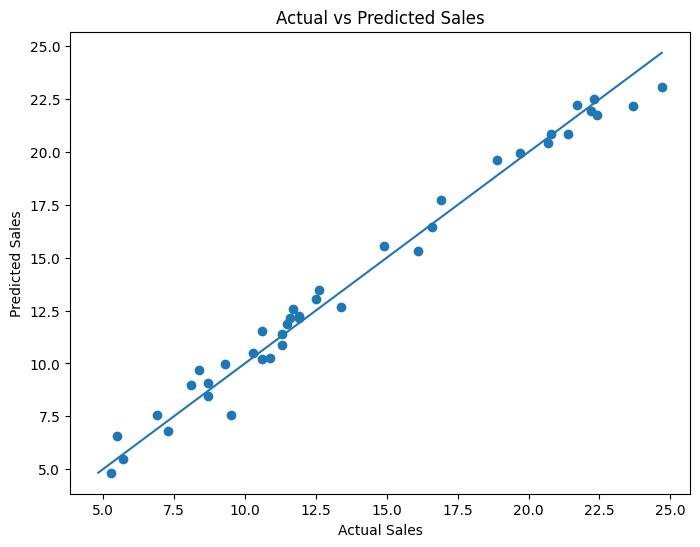

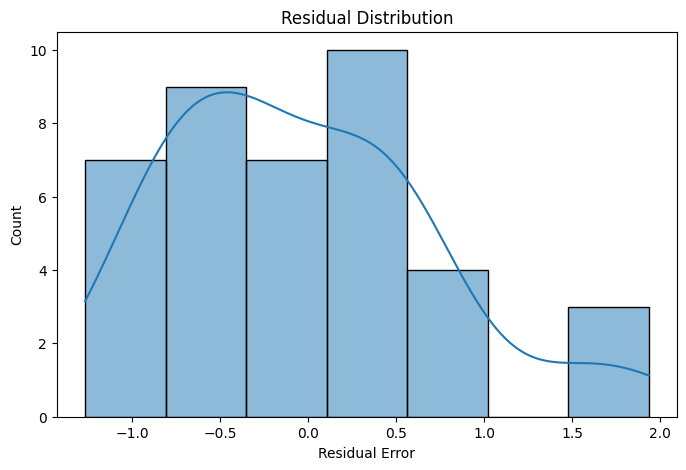


Feature Importance
     Feature  Importance
0         TV    0.625447
1      Radio    0.361745
2  Newspaper    0.012808


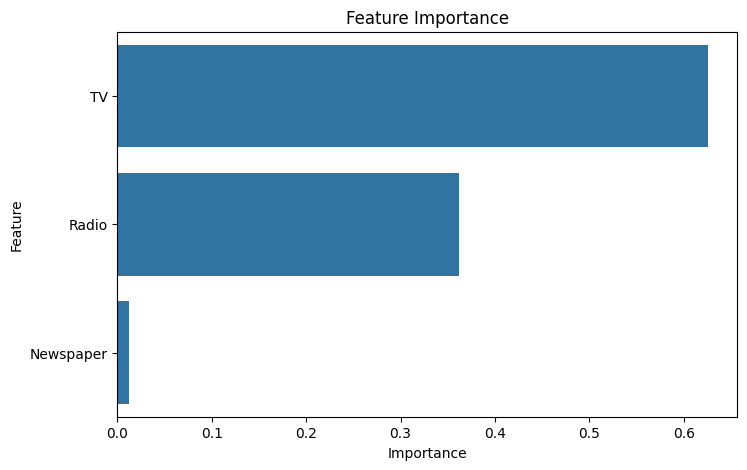


SALES FORECAST EXAMPLE
Predicted Sales : 21.96

Model Saved Successfully
File : sales_prediction_model.pkl

PROJECT SUMMARY
             Metric          Value
0        Best Model  Random Forest
1          R² Score         0.9826
2               MAE         0.6131
3              RMSE         0.7403
4  Training Samples            160
5   Testing Samples             40

Top 10 Prediction Results
   Actual Sales  Predicted Sales
0          16.9            17.73
1          22.4            21.74
2          21.4            20.87
3           7.3             6.82
4          24.7            23.10
5          12.6            13.47
6          22.3            22.50
7           8.4             9.67
8          11.5            11.85
9          14.9            15.55

Task 4 Completed Successfully!


In [5]:
# CODSOFT : DATA SCIENCE
# TASK 4 : SALES PREDICTION USING PYTHON
# AUTHOR : SALIK KHAN

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# LOAD DATASET

DATA_URL = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"

df = pd.read_csv(DATA_URL)

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df.columns = ["TV", "Radio", "Newspaper", "Sales"]
print("="*60)
print("ADVERTISING DATASET LOADED SUCCESSFULLY")
print("="*60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nFirst 5 Records")
print(df.head())


# DATA QUALITY REPORT


print("\n" + "="*60)
print("DATA QUALITY REPORT")
print("="*60)

duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")
print(f"Missing Values    : {df.isnull().sum().sum()}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"{duplicates} duplicate records removed.")
else:
    print("No duplicate records found.")

quality_report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

print("\nQuality Report")
print(quality_report)


# DATASET INFORMATION


print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())


# FEATURE DISTRIBUTION


fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,8)
)

sns.histplot(
    df["TV"],
    kde=True,
    ax=axes[0,0]
)
axes[0,0].set_title("TV Advertising")

sns.histplot(
    df["Radio"],
    kde=True,
    ax=axes[0,1]
)
axes[0,1].set_title("Radio Advertising")

sns.histplot(
    df["Newspaper"],
    kde=True,
    ax=axes[1,0]
)
axes[1,0].set_title("Newspaper Advertising")

sns.histplot(
    df["Sales"],
    kde=True,
    ax=axes[1,1]
)
axes[1,1].set_title("Sales Distribution")

plt.tight_layout()
plt.show()


# CORRELATION HEATMAP


plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# PAIRPLOT


sns.pairplot(df)

plt.show()

# SALES VS FEATURES


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

sns.scatterplot(
    data=df,
    x="TV",
    y="Sales",
    ax=axes[0]
)

axes[0].set_title("TV vs Sales")

sns.scatterplot(
    data=df,
    x="Radio",
    y="Sales",
    ax=axes[1]
)

axes[1].set_title("Radio vs Sales")

sns.scatterplot(
    data=df,
    x="Newspaper",
    y="Sales",
    ax=axes[2]
)

axes[2].set_title("Newspaper vs Sales")

plt.tight_layout()
plt.show()


# BOXPLOT ANALYSIS

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16,4)
)

for i, col in enumerate(df.columns):

    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()
plt.show()


# BUSINESS INSIGHTS


print("\nBUSINESS INSIGHTS")
print("="*60)

correlation = df.corr()["Sales"].sort_values(
    ascending=False
)

print(correlation)

print("\nObservation:")
print("TV advertising shows the strongest positive relationship with Sales.")
print("Radio advertising also contributes significantly to Sales.")
print("Newspaper advertising has comparatively lower influence.")

# FEATURES AND TARGET

X = df.drop(
    "Sales",
    axis=1
)

y = df["Sales"]

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("Sales")


# TRAIN TEST SPLIT

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTrain-Test Split")
print(f"X_train Shape : {X_train.shape}")
print(f"X_test Shape  : {X_test.shape}")
print(f"y_train Shape : {y_train.shape}")
print(f"y_test Shape  : {y_test.shape}")

# IMPORT MODELS

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# MODEL COMPARISON


models = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(
            random_state=42
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=300,
            random_state=42
        )
}

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = {}

print("\nMODEL COMPARISON")
print("="*60)

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="r2"
    )

    results[name] = scores.mean()

    print(
        f"{name:<20}"
        f" R² Score = {scores.mean():.4f}"
        f" (+/- {scores.std():.4f})"
    )


# MODEL RANKING


comparison = pd.DataFrame(
    results.items(),
    columns=["Model","R2 Score"]
)

comparison = comparison.sort_values(
    by="R2 Score",
    ascending=False
)

print("\nModel Ranking")
print(comparison)


# VISUALIZE MODEL COMPARISON


plt.figure(figsize=(8,4))

sns.barplot(
    data=comparison,
    x="R2 Score",
    y="Model"
)

plt.title("Model Comparison")

plt.show()


# BEST MODEL


best_model_name = comparison.iloc[0]["Model"]

print("\nBest Model Selected:")
print(best_model_name)

best_model = models[best_model_name]

# TRAIN BEST MODEL
\
best_model.fit(
    X_train,
    y_train
)

print("\nBest Model Trained Successfully!")

# PREDICTIONS

y_pred = best_model.predict(
    X_test
)
# EVALUATION METRICS

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")

# PREDICTION TABLE


prediction_df = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": np.round(
        y_pred,
        2
    )
})

print("\nSample Predictions")
print(
    prediction_df.head(10)
)

# ACTUAL VS PREDICTED


plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title(
    "Actual vs Predicted Sales"
)

line_min = min(
    y_test.min(),
    y_pred.min()
)

line_max = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [line_min, line_max],
    [line_min, line_max]
)

plt.show()

# RESIDUAL ANALYSIS

residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    "Residual Distribution"
)

plt.xlabel("Residual Error")

plt.show()

# FEATURE IMPORTANCE

if best_model_name == "Random Forest":

    importance_df = pd.DataFrame({

        "Feature": X.columns,

        "Importance":
            best_model.feature_importances_
    })

    importance_df = (
        importance_df
        .sort_values(
            by="Importance",
            ascending=False
        )
    )

    print("\nFeature Importance")
    print(importance_df)

    plt.figure(figsize=(8,5))

    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature"
    )

    plt.title(
        "Feature Importance"
    )

    plt.show()

# SALES FORECAST EXAMPLE


sample_campaign = pd.DataFrame({

    "TV": [230.1],

    "Radio": [37.8],

    "Newspaper": [69.2]
})

predicted_sales = (
    best_model.predict(
        sample_campaign
    )
)

print("\nSALES FORECAST EXAMPLE")
print("="*60)

print(
    f"Predicted Sales : "
    f"{predicted_sales[0]:.2f}"
)

# MODEL SAVING

import joblib

joblib.dump(
    best_model,
    "sales_prediction_model.pkl"
)

print(
    "\nModel Saved Successfully"
)

print(
    "File : sales_prediction_model.pkl"
)

# BUSINESS DASHBOARD

summary = pd.DataFrame({

    "Metric": [

        "Best Model",

        "R² Score",

        "MAE",

        "RMSE",

        "Training Samples",

        "Testing Samples"
    ],

    "Value": [

        best_model_name,

        round(r2,4),

        round(mae,4),

        round(rmse,4),

        X_train.shape[0],

        X_test.shape[0]
    ]
})

print("\nPROJECT SUMMARY")
print("="*60)

print(summary)

# TOP 10 PREDICTIONS


print("\nTop 10 Prediction Results")

print(
    prediction_df.head(10)
)

print("\nTask 4 Completed Successfully!")